In [2]:
!pip install kaggle


In [20]:
import kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c titanic

!unzip titanic.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
100% 34.1k/34.1k [00:00<00:00, 49.5MB/s]

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [21]:
import pandas as pd

# Load the Titanic dataset
titanic_data = pd.read_csv('train.csv')

# Explore the dataset
print(titanic_data.head())
print(titanic_data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

# Exercise 1: Remove Duplicates

In [22]:
#First check if there are duplicates
print(titanic_data.duplicated().sum())
#Then remove them
titanic_data=titanic_data.drop_duplicates()

0


# Exercise 2: Missing Values

In [23]:
missing=titanic_data.isnull
print(missing)

<bound method DataFrame.isnull of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [25]:
# Identify columns with missing values
missing_counts = titanic_data.isnull().sum()

# Filter for columns that actually have missing values (count > 0)
columns_with_missing = missing_counts[missing_counts > 0]

if not columns_with_missing.empty:
    print("Columns with missing values and their counts:")
    print(columns_with_missing)
    print("\nData types of columns with missing values:")
    for col_name, count in columns_with_missing.items():
        print(f"Column: {col_name}, Type: {titanic_data[col_name].dtype}")
else:
    print("No missing values found in the DataFrame.")

Columns with missing values and their counts:
Age         177
Cabin       687
Embarked      2
dtype: int64

Data types of columns with missing values:
Column: Age, Type: float64
Column: Cabin, Type: object
Column: Embarked, Type: object


### Handling Missing Values for 'Age'

For the 'Age' column, which is numerical, a common strategy is to impute missing values with the median. The median is robust to outliers compared to the mean.

In [26]:
# Impute missing 'Age' values with the median
median_age = titanic_data['Age'].median()
titanic_data['Age'].fillna(median_age, inplace=True)

print(f"Missing 'Age' values after imputation: {titanic_data['Age'].isnull().sum()}")

Missing 'Age' values after imputation: 0


/tmp/ipykernel_7909/1101795153.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(median_age, inplace=True)


### Handling Missing Values for 'Embarked'

For 'Embarked', a categorical column with only a few missing values, we can fill them with the mode (most frequent value).

In [27]:
# Impute missing 'Embarked' values with the mode
most_frequent_embark = titanic_data['Embarked'].mode()[0] # .mode() returns a Series, take the first element
titanic_data['Embarked'].fillna(most_frequent_embark, inplace=True)

print(f"Missing 'Embarked' values after imputation: {titanic_data['Embarked'].isnull().sum()}")

Missing 'Embarked' values after imputation: 0


/tmp/ipykernel_7909/3133349967.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(most_frequent_embark, inplace=True)


### Handling Missing Values for 'Cabin'

The 'Cabin' column has a large number of missing values. One approach is to fill them with a new category, such as 'Unknown', to indicate that the cabin information is missing, rather than dropping the column entirely, which could discard potentially useful information (e.g., that the passenger did not have a recorded cabin).

In [28]:
# Fill missing 'Cabin' values with 'Unknown'
titanic_data['Cabin'].fillna('Unknown', inplace=True)

print(f"Missing 'Cabin' values after imputation: {titanic_data['Cabin'].isnull().sum()}")

Missing 'Cabin' values after imputation: 0


/tmp/ipykernel_7909/1536474934.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Cabin'].fillna('Unknown', inplace=True)


### Verify all missing values are handled

In [29]:
print("Missing values in the DataFrame after handling:")
print(titanic_data.isnull().sum())

Missing values in the DataFrame after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# Exercise 3: Feature Engineering

### Creating `FamilySize` Feature

Combine `SibSp` (siblings/spouses) and `Parch` (parents/children) to create a `FamilySize` feature. We add 1 to include the passenger themselves.

In [30]:
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1

print(titanic_data[['SibSp', 'Parch', 'FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


### Extracting `Title` from `Name`

We can extract titles from the 'Name' column, which can be a good indicator of social status and gender. We'll then simplify some titles.

In [31]:
import re

def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\\.', name)
    if title_search:
        return title_search.group(1)
    return ""

titanic_data['Title'] = titanic_data['Name'].apply(get_title)

# Group less common titles
titanic_data['Title'] = titanic_data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

titanic_data['Title'] = titanic_data['Title'].replace('Mlle', 'Miss')
titanic_data['Title'] = titanic_data['Title'].replace('Ms', 'Miss')
titanic_data['Title'] = titanic_data['Title'].replace('Mme', 'Mrs')

print(titanic_data['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


### Encoding Categorical Variables

Convert 'Sex', 'Embarked', and the new 'Title' features into numerical format using one-hot encoding. We will drop the original categorical columns.

In [32]:
from sklearn.preprocessing import OneHotEncoder

# Select categorical columns to encode
categorical_cols = ['Sex', 'Embarked', 'Title']

# Initialize OneHotEncoder
# handle_unknown='ignore' will set unknown categories to all zeros, preventing errors during transformation
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the data
encoded_features = encoder.fit_transform(titanic_data[categorical_cols])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate the encoded features with the original DataFrame (dropping original categorical columns)
titanic_data = pd.concat([titanic_data.drop(columns=categorical_cols), encoded_df], axis=1)

print(titanic_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare    Cabin  ...  Sex_female  Sex_male  Embarked_C  \
0         A/5 21171   7.2500  Unknown  ...         0.0       1.0         0.0   
1          PC 17599  71.2833      C85  ...         1.0       0.0         1.0   
2  STON/O2. 3101282   7.9250  Unknown  ...         1.0       0.0         0.0   
3     

# Exercise 4: Removing Outliers


Original number of rows: 775
Lower Bound for Fare:  -19.260499999999997
Upper Bound for Fare:  53.1563
Number of Outliers detected (Fare):  25
Number of rows after outlier removal: 750


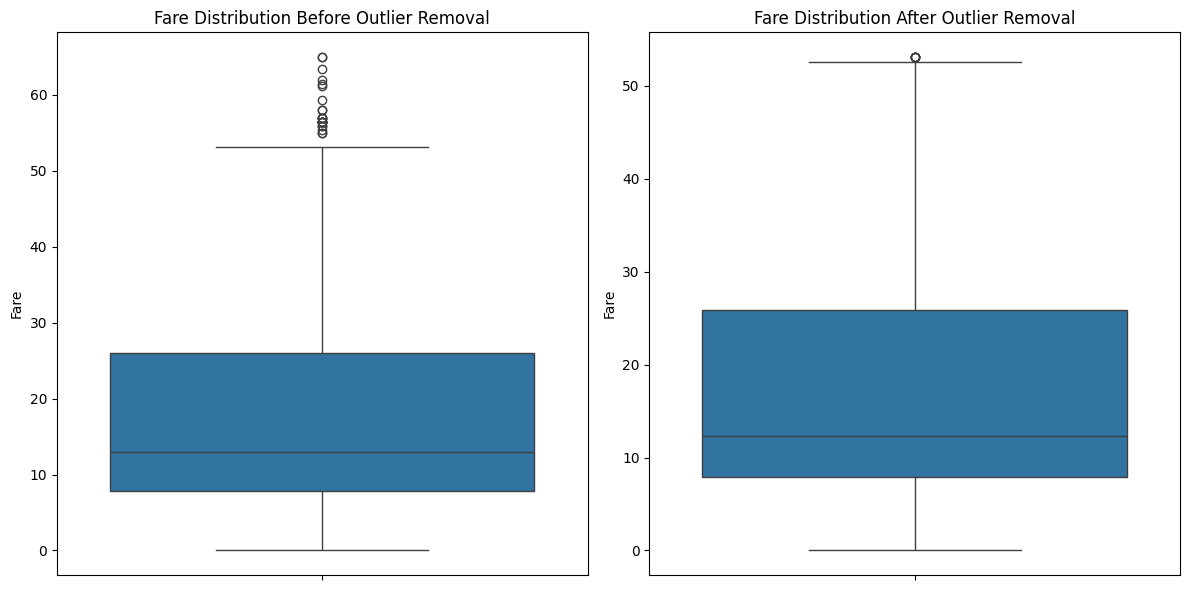

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize 'Fare' distribution before outlier removal
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=titanic_data['Fare'])
plt.title('Fare Distribution Before Outlier Removal')
plt.ylabel('Fare')

# Calculate IQR for 'Fare'
Q1 = titanic_data['Fare'].quantile(0.25)
Q3 = titanic_data['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Original number of rows: {len(titanic_data)}")
print("Lower Bound for Fare: ", lower_bound)
print("Upper Bound for Fare: ", upper_bound)
num_outliers = titanic_data[(titanic_data['Fare'] < lower_bound) | (titanic_data['Fare'] > upper_bound)].shape[0]
print("Number of Outliers detected (Fare): ", num_outliers)

# Remove outliers from 'Fare'
titanic_data = titanic_data[(titanic_data['Fare'] >= lower_bound) & (titanic_data['Fare'] <= upper_bound)]

print(f"Number of rows after outlier removal: {len(titanic_data)}")

# Visualize 'Fare' distribution after outlier removal
plt.subplot(1, 2, 2)
sns.boxplot(y=titanic_data['Fare'])
plt.title('Fare Distribution After Outlier Removal')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

# Exercise 5: Normalization


### Identifying Numerical Features for Scaling

First, let's identify the numerical columns that are candidates for scaling. We'll exclude `PassengerId` (an identifier), `Survived` (the target variable), and the one-hot encoded columns which are already binary.

In [36]:
numerical_cols_for_scaling = [
    'Age',
    'Fare',
    'FamilySize',
    'Pclass' # Pclass is an ordinal numerical feature
]

print("Numerical columns identified for scaling:", numerical_cols_for_scaling)

Numerical columns identified for scaling: ['Age', 'Fare', 'FamilySize', 'Pclass']


### Visualize Distributions and Calculate Skewness

Now, let's visualize the distribution of these numerical columns using histograms and density plots. We'll also calculate the skewness value for each to quantify their distribution shape. A skewness value close to 0 suggests a normal distribution, while positive or negative values indicate skewness.

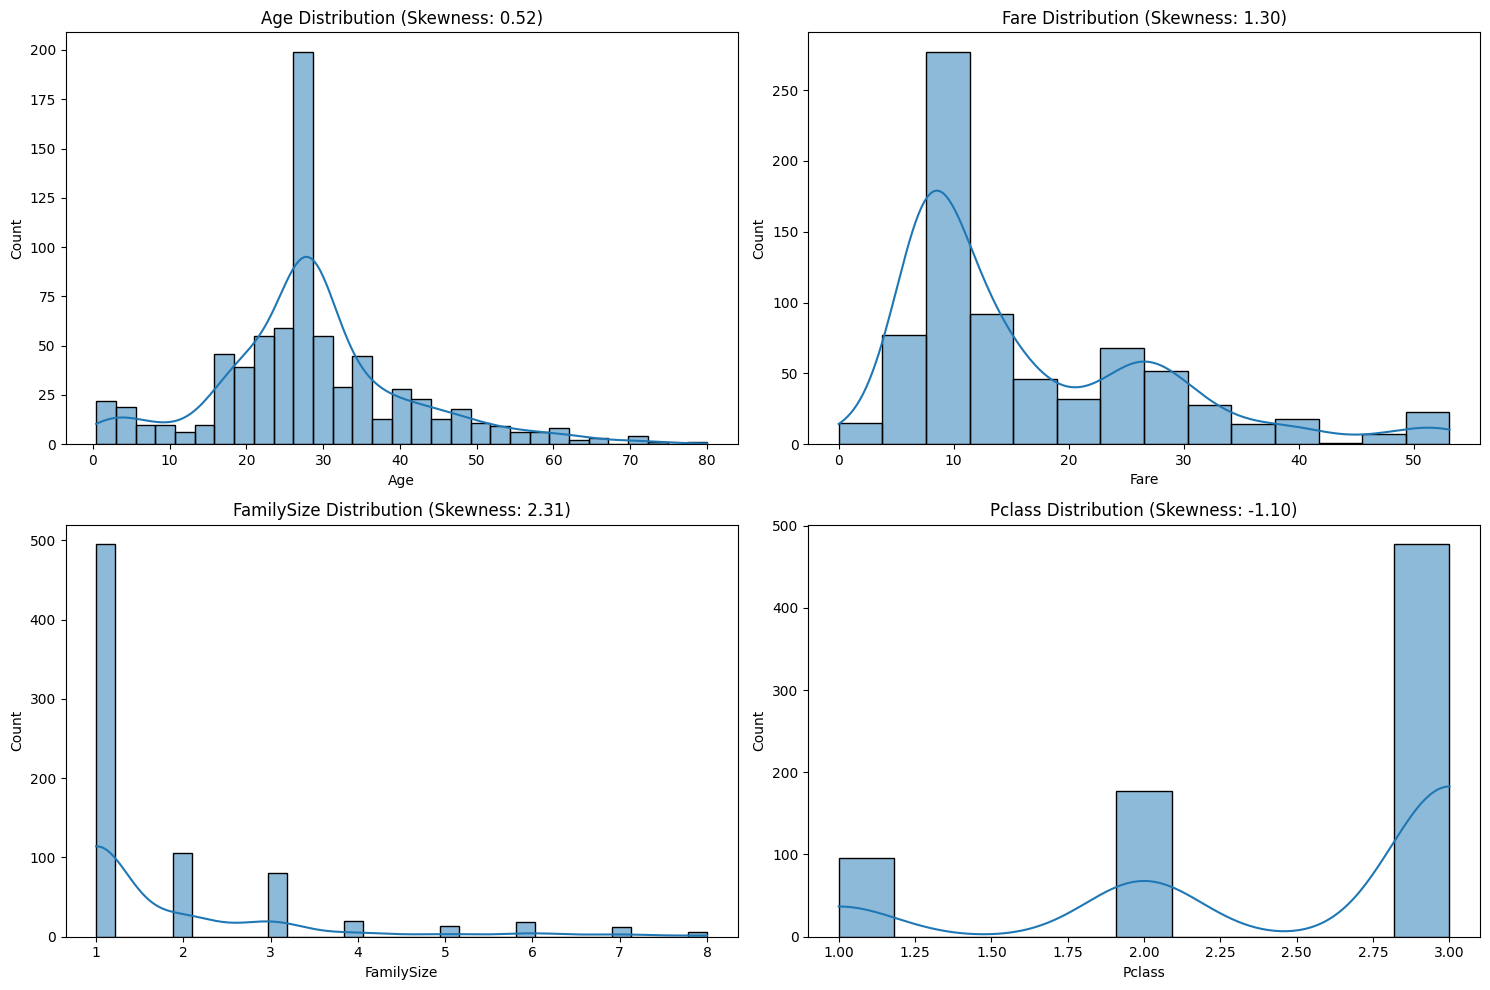

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_scaling):
    plt.subplot(2, 2, i + 1)
    sns.histplot(titanic_data[col], kde=True)
    plt.title(f'{col} Distribution (Skewness: {titanic_data[col].skew():.2f})')
plt.tight_layout()
plt.show()

Based on the visualizations and skewness values:

*   **Age**: The distribution of `Age` appears relatively symmetric (skewness close to 0) and somewhat bell-shaped, suggesting it could be treated as approximately normally distributed.
*   **Fare**: The `Fare` distribution is positively skewed, even after outlier removal.
*   **FamilySize**: The `FamilySize` distribution is also positively skewed.
*   **Pclass**: `Pclass` is an ordinal feature with a discrete distribution. While not truly 'normal', it's often treated with standardization if the range isn't fixed.

Therefore, we'll proceed with:
*   `StandardScaler` for `Age` and `Pclass`.
*   `MinMaxScaler` for `Fare` and `FamilySize`.

In [38]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialize scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Apply StandardScaler to 'Age' and 'Pclass'
titanic_data[['Age', 'Pclass']] = scaler_standard.fit_transform(titanic_data[['Age', 'Pclass']])

# Apply MinMaxScaler to 'Fare' and 'FamilySize'
titanic_data[['Fare', 'FamilySize']] = scaler_minmax.fit_transform(titanic_data[['Fare', 'FamilySize']])

print("DataFrame after scaling numerical features:")
print(titanic_data[numerical_cols_for_scaling].head())
print("\nDescriptive statistics after scaling:")
print(titanic_data[numerical_cols_for_scaling].describe())

DataFrame after scaling numerical features:
        Age      Fare  FamilySize    Pclass
0 -0.514667  0.136535    0.142857  0.691699
2 -0.200606  0.149247    0.000000  0.691699
3  0.506031  1.000000    0.142857 -2.120086
4  0.506031  0.151601    0.000000  0.691699
5 -0.043576  0.159290    0.000000  0.691699

Descriptive statistics after scaling:
                Age        Fare  FamilySize        Pclass
count  7.500000e+02  750.000000  750.000000  7.500000e+02
mean   2.842171e-17    0.310315    0.110857 -5.684342e-17
std    1.000667e+00    0.218102    0.204735  1.000667e+00
min   -2.209026e+00    0.000000    0.000000 -2.120086e+00
25%   -5.146673e-01    0.148697    0.000000 -7.141935e-01
50%   -4.357595e-02    0.231285    0.000000  6.916993e-01
75%    4.275154e-01    0.486641    0.142857  6.916993e-01
max    4.039216e+00    1.000000    1.000000  6.916993e-01


# Feature Encoding


In [39]:
# Exercise 6: Feature Encoding
# Identifying and encoding remaining categorical columns.

# Get a list of all object type columns remaining in the DataFrame.
# These are typically categorical columns that might need further encoding if not already handled.
remaining_categorical_cols = titanic_data.select_dtypes(include=['object']).columns.tolist()

if remaining_categorical_cols:
    print("Remaining categorical columns to consider for encoding:")
    print(remaining_categorical_cols)
    # If there were other categorical columns, one-hot encoding would be a common approach.
    # For example:
    # from sklearn.preprocessing import OneHotEncoder
    # encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    # encoded_other_features = encoder.fit_transform(titanic_data[remaining_categorical_cols])
    # encoded_other_df = pd.DataFrame(encoded_other_features, columns=encoder.get_feature_names_out(remaining_categorical_cols))
    # titanic_data = pd.concat([titanic_data.drop(columns=remaining_categorical_cols), encoded_other_df], axis=1)
    # print("\nDataFrame after encoding remaining categorical features:")
    # print(titanic_data.head())
else:
    print("All major categorical columns (Sex, Embarked, Title) have already been one-hot encoded.")
    print("No other 'object' type columns found requiring encoding at this stage.")

# Display the current state of the DataFrame to show encoded features
print("\nDataFrame columns after all previous processing steps:")
print(titanic_data.columns.tolist())

Remaining categorical columns to consider for encoding:
['Name', 'Ticket', 'Cabin']

DataFrame columns after all previous processing steps:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'FamilySize', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


Given the output, the `Name` and `Ticket` columns are typically not used directly for modeling due to their unique string nature and high cardinality, respectively. The `Name` column's useful information (Title) has already been extracted. We will drop these two columns.

The `Cabin` column, while having many 'Unknown' values, is now a categorical feature and can be one-hot encoded along with any other remaining relevant categorical columns.

In [40]:
# Drop 'Name' and 'Ticket' columns as they are not typically used for modeling directly
titanic_data = titanic_data.drop(columns=['Name', 'Ticket'])

# Identify remaining categorical columns to encode (which should now primarily be 'Cabin')
remaining_categorical_cols_to_encode = titanic_data.select_dtypes(include=['object']).columns.tolist()

if remaining_categorical_cols_to_encode:
    print("Encoding remaining categorical columns:", remaining_categorical_cols_to_encode)
    # Apply OneHotEncoder for the remaining categorical columns (e.g., 'Cabin')
    encoder_remaining = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_remaining_features = encoder_remaining.fit_transform(titanic_data[remaining_categorical_cols_to_encode])
    encoded_remaining_df = pd.DataFrame(encoded_remaining_features, columns=encoder_remaining.get_feature_names_out(remaining_categorical_cols_to_encode))

    # Concatenate the encoded features with the original DataFrame (dropping original columns)
    titanic_data = pd.concat([titanic_data.drop(columns=remaining_categorical_cols_to_encode), encoded_remaining_df], axis=1)

    print("\nDataFrame after encoding remaining categorical features:")
    print(titanic_data.head())
else:
    print("No further object-type categorical columns found for encoding.")

print("\nFinal DataFrame columns after all processing steps:")
print(titanic_data.columns.tolist())

Encoding remaining categorical columns: ['Cabin']

DataFrame after encoding remaining categorical features:
   PassengerId  Survived    Pclass       Age  SibSp  Parch      Fare  \
0          1.0       0.0  0.691699 -0.514667    1.0    0.0  0.136535   
2          3.0       1.0  0.691699 -0.200606    0.0    0.0  0.149247   
3          4.0       1.0 -2.120086  0.506031    1.0    0.0  1.000000   
4          5.0       0.0  0.691699  0.506031    0.0    0.0  0.151601   
5          6.0       0.0  0.691699 -0.043576    0.0    0.0  0.159290   

   FamilySize  Sex_female  Sex_male  ...  Cabin_F E69  Cabin_F G63  \
0    0.142857         0.0       1.0  ...          0.0          0.0   
2    0.000000         1.0       0.0  ...          0.0          0.0   
3    0.142857         1.0       0.0  ...          0.0          0.0   
4    0.000000         0.0       1.0  ...          0.0          0.0   
5    0.000000         0.0       1.0  ...          0.0          0.0   

   Cabin_F G73  Cabin_F2  Cabin_F33  C

# Exercise 7: Data Transformation

### Creating and Encoding Age Groups

We will create bins for the 'Age' feature to categorize passengers into different life stages (e.g., Child, Teen, Adult, Senior). These new categories will then be one-hot encoded.

In [43]:
# Define age labels for life stages
age_labels = ['Child', 'Teen', 'Adult', 'Senior']

# Create the 'AgeGroup' feature using pd.qcut()
# pd.qcut divides the data into equal-sized quantiles, which is suitable for scaled data
# We'll use 4 quantiles to correspond to the 4 labels.
titanic_data['AgeGroup'] = pd.qcut(titanic_data['Age'], q=4, labels=age_labels, precision=1)

print("AgeGroup counts before encoding:")
print(titanic_data['AgeGroup'].value_counts())

# Apply one-hot encoding to the 'AgeGroup' feature
age_group_encoded = pd.get_dummies(titanic_data['AgeGroup'], prefix='AgeGroup', dtype=int)

# Concatenate the new one-hot encoded columns with the original DataFrame
titanic_data = pd.concat([titanic_data, age_group_encoded], axis=1)

# Drop the original 'AgeGroup' column as it's now encoded
titanic_data.drop('AgeGroup', axis=1, inplace=True)

print("\nDataFrame head after creating and encoding AgeGroup:")
print(titanic_data.head())

print("\nFinal DataFrame columns after all processing steps:")
print(titanic_data.columns.tolist())

AgeGroup counts before encoding:
AgeGroup
Teen      269
Child     204
Senior    176
Adult     101
Name: count, dtype: int64

DataFrame head after creating and encoding AgeGroup:
   PassengerId  Survived    Pclass       Age  SibSp  Parch      Fare  \
0          1.0       0.0  0.691699 -0.514667    1.0    0.0  0.136535   
2          3.0       1.0  0.691699 -0.200606    0.0    0.0  0.149247   
3          4.0       1.0 -2.120086  0.506031    1.0    0.0  1.000000   
4          5.0       0.0  0.691699  0.506031    0.0    0.0  0.151601   
5          6.0       0.0  0.691699 -0.043576    0.0    0.0  0.159290   

   FamilySize  Sex_female  Sex_male  ...  Cabin_F33  Cabin_F38  Cabin_F4  \
0    0.142857         0.0       1.0  ...        0.0        0.0       0.0   
2    0.000000         1.0       0.0  ...        0.0        0.0       0.0   
3    0.142857         1.0       0.0  ...        0.0        0.0       0.0   
4    0.000000         0.0       1.0  ...        0.0        0.0       0.0   
5    0.00